In [1]:
# Standard Imports
import numpy as np
import random
import matplotlib.pyplot as plt

# Wavelet
import pywt

# Utils
from config import *
from utils.display import loadAndDisplay, getTemporalSignals
from utils.wavelet import applyAndCompareWTMethods

In [2]:
norm_fmri_dict = loadAndDisplay(FMRI_NORM_PATH, "FMRI NORMALIZED", print_summary = True)


INFORMATION ABOUT FMRI NORMALIZED NIFTI FILE:

----------------------------------------------------------------------------------------------------
Type of variable nii_img: <class 'nibabel.nifti1.Nifti1Image'>
Type of variable nii_hdr: <class 'nibabel.nifti1.Nifti1Header'>
Shape of the NIfTI image: (91, 109, 91, 200)
Dimensions of the NIfTI image: [  4  91 109  91]
Dimensions of NIfTI img data: (91, 109, 91, 200)
Voxel size (mm): (2.0, 2.0, 2.0, 3.56)


## IMPORTANT

In this part of the project we are using the Wavelet to analyze 1D temporal signals. The Wavelet function implemented by the PYWT library requests in input the scale parameter, corresponding to the values for which to scale the Mother Wavelet, used to extract details from the 1D signal. It's important to give values of lower that are greater than the Niquist Limit otherwise the Wavelet will search for details that are not feasible.
- TR = 3.56 s ---> I'm getting data at a frequency of 0.28 Hz --> Nyquist Limit = 0.14 Hz --> I cannot capture with the Wavelet events that happen more than 0.14 times per second
- I can use scale ranges from 0.01 to 0.1

### Here I extract an arbitrary number of temporal signals from time_series

In [3]:
time_series = np.load("data/part3/time_series.npy")
signals = getTemporalSignals(time_series, count=4) # 200 x 4

### Some usefull documentation: https://pywavelets.readthedocs.io/en/latest/ref/cwt.html

- scalesarray_like
    The wavelet scales to use. One can use f = scale2frequency(wavelet, scale)/sampling_period to determine what physical frequency, f. Here, f is in hertz when the sampling_period is given in seconds.

- example: scales = np.logspace(np.log10(1), np.log10(128), 128)

- Type of wavelets (the formula change): mexican hat, morlet, complex morlet, gaussian derivative, shannon


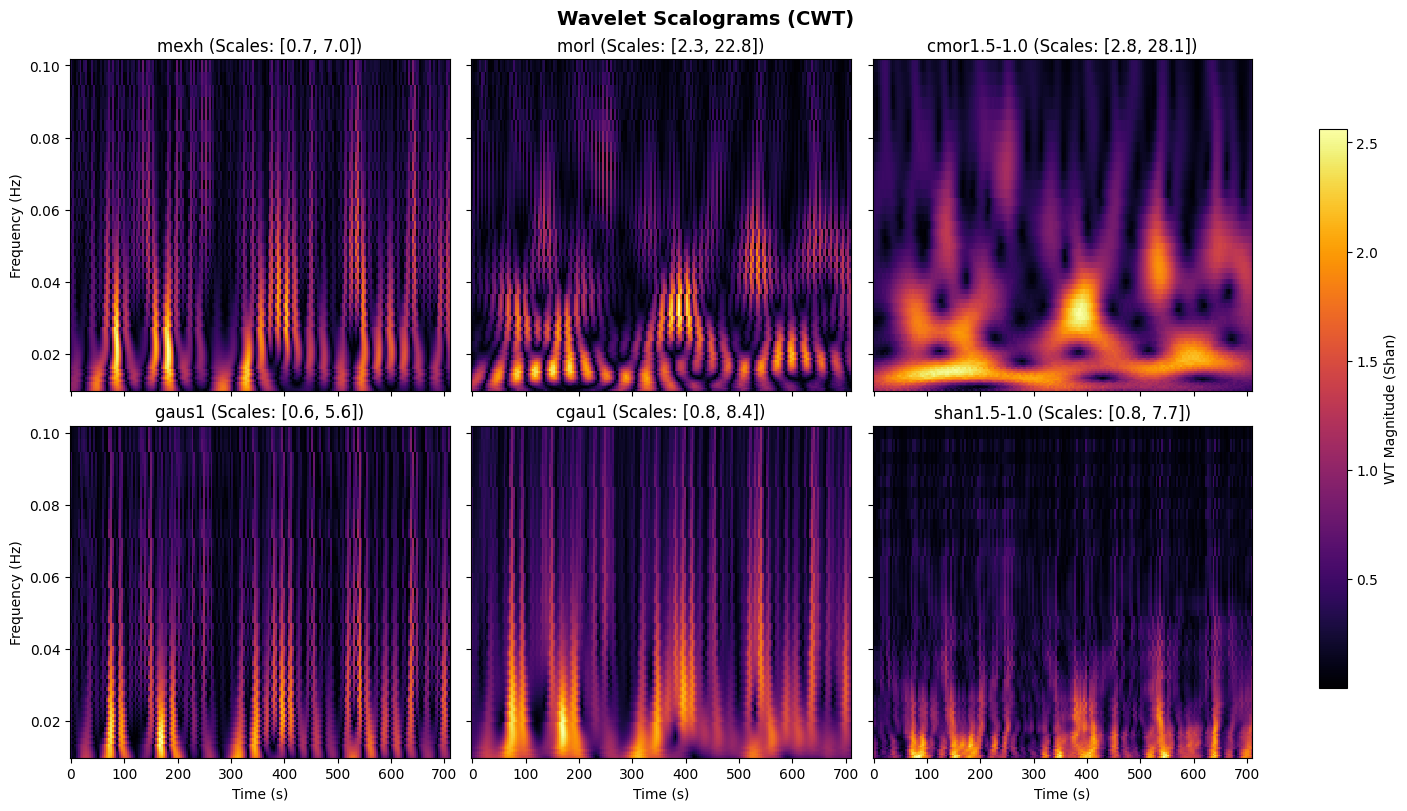

In [4]:
TR = 3.56 # Time Period
freqs_range = [0.01, 0.1]

applyAndCompareWTMethods(signals[:,0], TR, freqs_range)

### Signal 1 - Observations
per tutta la durata del segnale sembra esserci attivazione alta, e a fine segnale sembra esserci attivazione alta anche a frequenze più alte

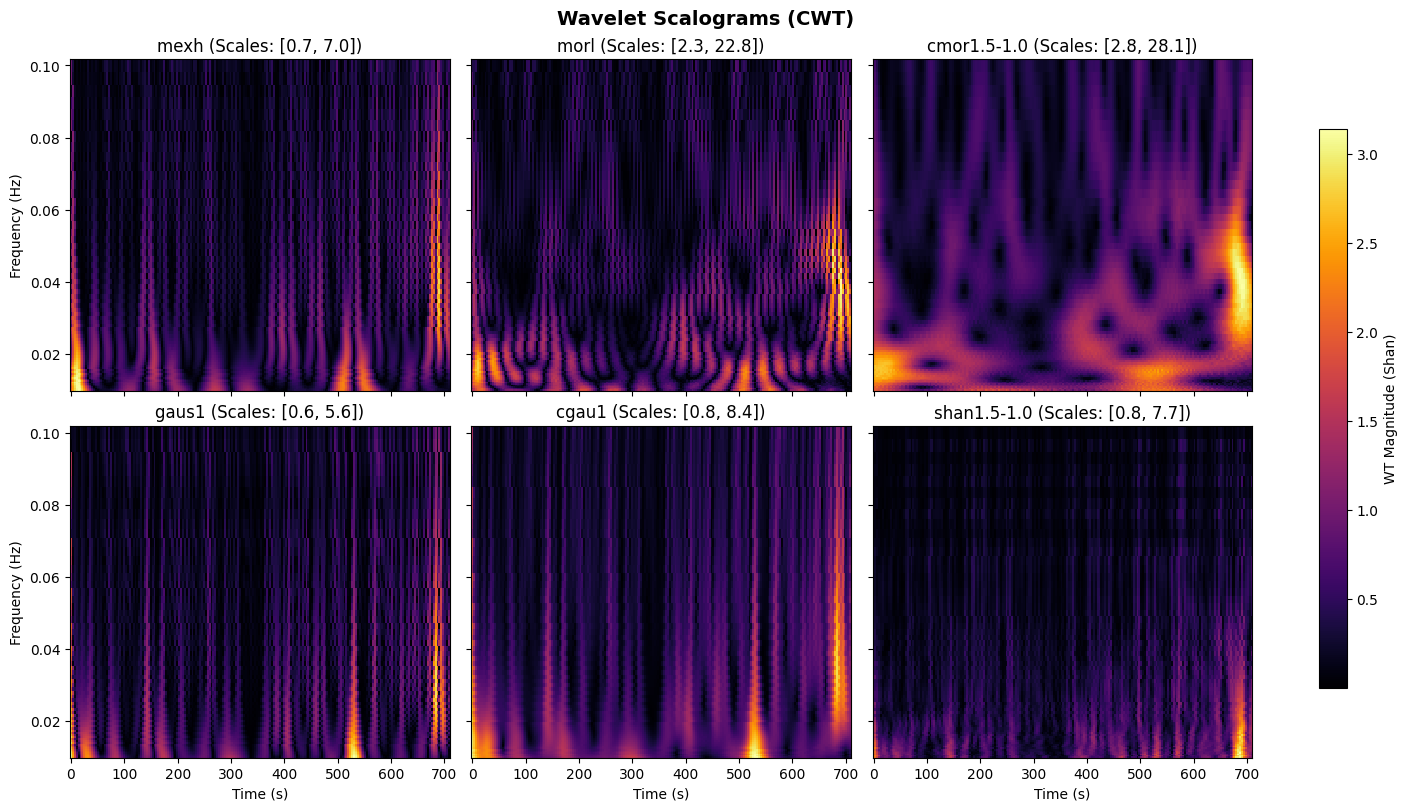

In [5]:
applyAndCompareWTMethods(signals[:,1], TR, freqs_range)

### Signal 2 - Observations
Alta attivazione all'inizio e alla fine, alla fine a frequenze più alte

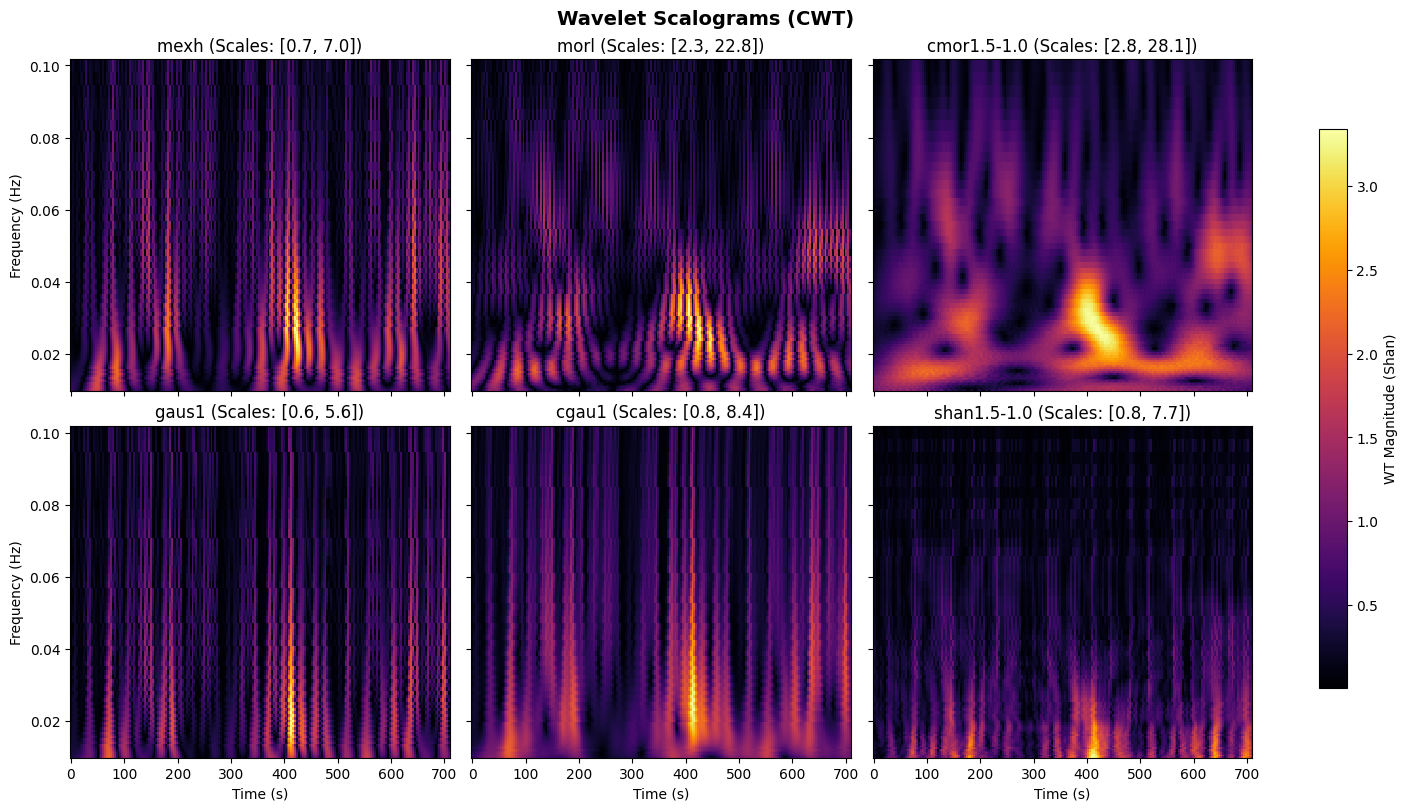

In [6]:
applyAndCompareWTMethods(signals[:,2], TR, freqs_range)

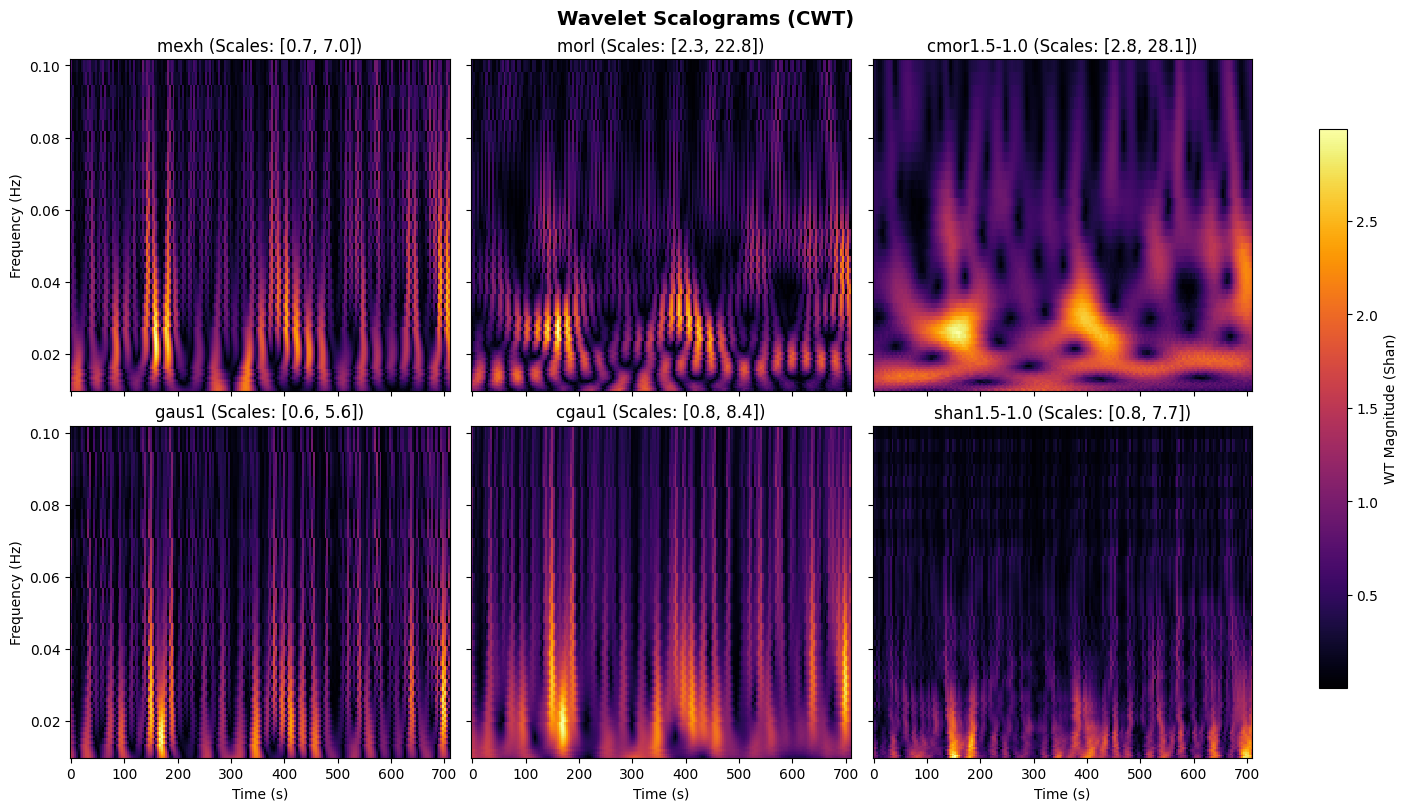

In [7]:
applyAndCompareWTMethods(signals[:,3], TR, freqs_range)